# データ分析コード - gpt-5用

実験ID: `20260102_081814_BFI20_PDI10_PDR100_Mgpt5`


In [21]:
# ===== ライブラリのインポートと設定 =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, ttest_ind # 統計分析と検定
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# プロジェクトルートの設定（ipynbファイルはプロジェクトルートに配置されていることを前提）
PROJECT_ROOT = Path.cwd().parent
if (PROJECT_ROOT / "main.py").exists():
    # main.pyが存在する場合は、そのディレクトリがプロジェクトルート
    pass
else:
    # main.pyが見つからない場合は、親ディレクトリを確認
    PROJECT_ROOT = PROJECT_ROOT.parent

# 設定
EXPERIMENT_ID = "20260102_081814_BFI20_PDI10_PDR100_Mgpt5"
FIGURE_SIZE = (12, 8)
DPI = 300
FONT_FAMILY = 'DejaVu Sans'

# 日本語フォント設定
plt.rcParams['font.family'] = FONT_FAMILY
plt.rcParams['figure.figsize'] = FIGURE_SIZE
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("ライブラリのインポート完了")
print(f"実験ID: {EXPERIMENT_ID}")
print(f"プロジェクトルート: {PROJECT_ROOT}")


ライブラリのインポート完了
実験ID: 20260102_081814_BFI20_PDI10_PDR100_Mgpt5
プロジェクトルート: /Users/mizuki/dev/private/research/llm_personality_game


In [22]:
# ===== JSONファイルからデータを読み込む関数 =====
import json as json_module
from datetime import datetime

LOG_PATH = "/Users/mizuki/dev/private/research/llm_personality_game/.cursor/debug.log"

def debug_log(location, message, data, hypothesis_id=None):
    """デバッグログをNDJSON形式で書き込む"""
    # #region agent log
    try:
        log_entry = {
            "sessionId": "debug-session",
            "runId": "run1",
            "timestamp": int(datetime.now().timestamp() * 1000),
            "location": location,
            "message": message,
            "data": data
        }
        if hypothesis_id:
            log_entry["hypothesisId"] = hypothesis_id
        with open(LOG_PATH, 'a', encoding='utf-8') as f:
            f.write(json_module.dumps(log_entry, ensure_ascii=False) + '\n')
    except Exception:
        pass
    # #endregion

def load_game_data_from_json(file_path):
    """JSONファイルからゲームデータを読み込む"""
    # #region agent log
    debug_log("load_game_data_from_json:entry", "ファイル読み込み開始", {"file_path": str(file_path)}, "A")
    # #endregion
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    # #region agent log
    debug_log("load_game_data_from_json:exit", "ファイル読み込み完了", {"has_game_results": 'game_results' in data, "has_pd_results": 'pd_results' in data}, "A")
    # #endregion
    return data

def calculate_cooperation_rate_and_payoff(game_data):
    """ゲームデータから協力率とペイオフを計算"""
    results = []
    
    # #region agent log
    debug_log("calculate_cooperation_rate_and_payoff:entry", "関数開始", {}, "A")
    # #endregion
    
    # game_resultsまたはpd_resultsのどちらかをチェック
    game_results_key = None
    if 'game_results' in game_data:
        game_results_key = 'game_results'
    elif 'pd_results' in game_data:
        # pd_resultsの場合は、その中のgame_resultsを参照
        if 'game_results' in game_data['pd_results']:
            game_results_key = 'pd_results'
        else:
            # #region agent log
            debug_log("calculate_cooperation_rate_and_payoff:early_return", "pd_resultsにgame_resultsなし", {}, "A")
            # #endregion
            return results
    else:
        # #region agent log
        debug_log("calculate_cooperation_rate_and_payoff:early_return", "game_resultsもpd_resultsもなし", {}, "A")
        # #endregion
        return results
    
    if game_results_key:
        if game_results_key == 'game_results':
            game_results = game_data['game_results']
        else:  # pd_resultsの場合
            game_results = game_data['pd_results']['game_results']
        
        # #region agent log
        debug_log("calculate_cooperation_rate_and_payoff:before_loop", "戦略ループ開始前", {"strategies_count": len(game_results), "strategies": list(game_results.keys())}, "A")
        # #endregion
        
        for strategy, strategy_data in game_results.items():
            # #region agent log
            debug_log("calculate_cooperation_rate_and_payoff:strategy_start", "戦略処理開始", {"strategy": strategy, "has_repetition_details": isinstance(strategy_data, dict) and 'repetition_details' in strategy_data}, "B")
            # #endregion
            
            if isinstance(strategy_data, dict) and 'repetition_details' in strategy_data:
                repetition_details = strategy_data['repetition_details']
                num_games = len(repetition_details)
                
                # #region agent log
                debug_log("calculate_cooperation_rate_and_payoff:before_games_loop", "ゲームループ開始前", {"strategy": strategy, "num_games": num_games}, "B")
                # #endregion
                
                # 各戦略について、10ゲームの合計ペイオフを計算
                all_payoffs = []
                all_cooperation_actions = []
                game_rounds_info = []
                
                for rep_idx, rep_data in enumerate(repetition_details):
                    # #region agent log
                    debug_log("calculate_cooperation_rate_and_payoff:game_start", "ゲーム処理開始", {"strategy": strategy, "game_index": rep_idx, "repetition": rep_data.get('repetition', 'N/A')}, "C")
                    # #endregion
                    
                    if 'game_history' in rep_data and 'actions' in rep_data['game_history']:
                        actions = rep_data['game_history']['actions']
                        num_rounds = len(actions)
                        
                        # #region agent log
                        debug_log("calculate_cooperation_rate_and_payoff:game_actions", "ゲームのアクション数", {"strategy": strategy, "game_index": rep_idx, "num_rounds": num_rounds, "first_round_num": actions[0].get('round_num') if actions else None, "last_round_num": actions[-1].get('round_num') if actions else None}, "C")
                        # #endregion
                        
                        game_rounds_info.append(num_rounds)
                        
                        # 各ゲームのペイオフを合計
                        game_payoffs = [action['player_payoff'] for action in actions]
                        game_total_payoff = sum(game_payoffs)
                        all_payoffs.append(game_total_payoff)
                        
                        # 各ゲームの協力行動を記録
                        cooperation_actions = [action['player_action'] for action in actions]
                        all_cooperation_actions.extend(cooperation_actions)
                
                # #region agent log
                debug_log("calculate_cooperation_rate_and_payoff:after_games_loop", "ゲームループ終了後", {"strategy": strategy, "total_games_processed": len(all_payoffs), "total_rounds_collected": len(all_cooperation_actions), "game_rounds_info": game_rounds_info[:5]}, "B")
                # #endregion
                
                # 10ゲームの平均ペイオフを計算
                if all_payoffs:
                    total_payoff_all_games = sum(all_payoffs)
                    average_payoff = total_payoff_all_games / len(all_payoffs)  # 10ゲームの平均
                    
                    # 全ラウンドの協力率を計算
                    cooperation_rate = sum(all_cooperation_actions) / len(all_cooperation_actions) if all_cooperation_actions else 0
                    
                    # ラウンド別の協力行動（最初のゲームのデータを使用）
                    first_game_actions = strategy_data['repetition_details'][0]['game_history']['actions']
                    round_cooperation = [action['player_action'] for action in first_game_actions]
                    
                    # #region agent log
                    debug_log("calculate_cooperation_rate_and_payoff:result", "結果計算完了", {"strategy": strategy, "num_games": len(all_payoffs), "total_rounds": len(all_cooperation_actions), "cooperation_rate": cooperation_rate, "round_cooperation_length": len(round_cooperation), "average_payoff": average_payoff}, "B")
                    # #endregion
                    
                    results.append({
                        'strategy': strategy,
                        'repetition': 0,  # 全体の統計なので0に設定
                        'cooperation_rate': cooperation_rate,
                        'total_payoff': total_payoff_all_games,
                        'average_payoff': average_payoff,
                        'round_cooperation': round_cooperation
                    })
    
    # #region agent log
    debug_log("calculate_cooperation_rate_and_payoff:exit", "関数終了", {"results_count": len(results)}, "A")
    # #endregion
    
    return results

def load_all_conditions_data(experiment_id):
    """すべての条件のデータを読み込む"""
    # #region agent log
    debug_log("load_all_conditions_data:entry", "関数開始", {"experiment_id": experiment_id}, "D")
    # #endregion
    
    # まずpaper_resultsを確認、なければdataを確認
    paper_results_path = PROJECT_ROOT / "paper_results" / experiment_id
    data_path = PROJECT_ROOT / "data" / experiment_id
    
    if paper_results_path.exists():
        base_path = paper_results_path
        print(f"paper_resultsからデータを読み込み: {base_path}")
        # #region agent log
        debug_log("load_all_conditions_data:path_selected", "パス選択", {"path_type": "paper_results", "base_path": str(base_path)}, "D")
        # #endregion
    elif data_path.exists():
        base_path = data_path
        print(f"dataからデータを読み込み: {base_path}")
        # #region agent log
        debug_log("load_all_conditions_data:path_selected", "パス選択", {"path_type": "data", "base_path": str(base_path)}, "D")
        # #endregion
    else:
        # フォールバック: 相対パスでresultsを確認（後方互換性のため）
        base_path = PROJECT_ROOT / "results" / experiment_id
        print(f"resultsからデータを読み込み（フォールバック）: {base_path}")
        # #region agent log
        debug_log("load_all_conditions_data:path_selected", "パス選択", {"path_type": "results", "base_path": str(base_path)}, "D")
        # #endregion
    
    all_data = []
    
    # 1. no_prompt条件
    no_prompt_file = base_path / "BFIno_prompt_PDcompetitive" / "control_pd_games.json"
    # #region agent log
    debug_log("load_all_conditions_data:check_file", "ファイル存在確認", {"condition": "no_prompt", "file_path": str(no_prompt_file), "exists": no_prompt_file.exists()}, "D")
    # #endregion
    if no_prompt_file.exists():
        data = load_game_data_from_json(no_prompt_file)
        results = calculate_cooperation_rate_and_payoff(data)
        for result in results:
            result['condition'] = 'no_prompt'
            result['condition_detail'] = 'no_prompt'
        all_data.extend(results)
        print(f"no_prompt条件: {len(results)}件のデータを読み込み")
        # #region agent log
        debug_log("load_all_conditions_data:condition_loaded", "条件データ読み込み完了", {"condition": "no_prompt", "results_count": len(results)}, "D")
        # #endregion
    
    # 2. control条件
    control_file = base_path / "BFInumbers_and_language_PDcompetitive" / "control_pd_games.json"
    # #region agent log
    debug_log("load_all_conditions_data:check_file", "ファイル存在確認", {"condition": "control", "file_path": str(control_file), "exists": control_file.exists()}, "D")
    # #endregion
    if control_file.exists():
        data = load_game_data_from_json(control_file)
        results = calculate_cooperation_rate_and_payoff(data)
        for result in results:
            result['condition'] = 'control'
            result['condition_detail'] = 'control'
        all_data.extend(results)
        print(f"control条件: {len(results)}件のデータを読み込み")
        # #region agent log
        debug_log("load_all_conditions_data:condition_loaded", "条件データ読み込み完了", {"condition": "control", "results_count": len(results)}, "D")
        # #endregion
    
    # 3. 性格特性修正条件
    personality_modifications = [
        'agreeableness_score_1', 'agreeableness_score_5',
        'conscientiousness_score_1', 'conscientiousness_score_5',
        'extraversion_score_1', 'extraversion_score_5',
        'neuroticism_score_1', 'neuroticism_score_5',
        'openness_score_1', 'openness_score_5'
    ]
    
    for mod in personality_modifications:
        mod_file = base_path / "BFInumbers_and_language_PDcompetitive" / f"{mod}_modification_experiment.json"
        # #region agent log
        debug_log("load_all_conditions_data:check_file", "ファイル存在確認", {"condition": mod, "file_path": str(mod_file), "exists": mod_file.exists()}, "D")
        # #endregion
        
        if mod_file.exists():
            data = load_game_data_from_json(mod_file)
            
            # 性格特性修正データの構造: データはmodキーの下にある
            if mod in data:
                mod_data = data[mod]
                results = calculate_cooperation_rate_and_payoff(mod_data)
                
                for result in results:
                    result['condition'] = 'personality_modification'
                    result['condition_detail'] = mod
                all_data.extend(results)
                print(f"{mod}条件: {len(results)}件のデータを読み込み")
                # #region agent log
                debug_log("load_all_conditions_data:condition_loaded", "条件データ読み込み完了", {"condition": mod, "results_count": len(results)}, "D")
                # #endregion
            else:
                print(f"{mod}条件: データ構造が予期しない形式です")
                # #region agent log
                debug_log("load_all_conditions_data:condition_error", "条件データ構造エラー", {"condition": mod, "error": "modキーがデータに存在しない"}, "D")
                # #endregion
        else:
            print(f"{mod}条件: ファイルが見つかりません")
    
    # #region agent log
    debug_log("load_all_conditions_data:exit", "関数終了", {"total_data_count": len(all_data)}, "D")
    # #endregion
    
    return all_data

# データの読み込み実行
print(f"実験ID: {EXPERIMENT_ID}")
# #region agent log
debug_log("main:before_load", "データ読み込み開始前", {"experiment_id": EXPERIMENT_ID}, "D")
# #endregion
all_game_data = load_all_conditions_data(EXPERIMENT_ID)
print(f"総データ数: {len(all_game_data)}件")
# #region agent log
debug_log("main:after_load", "データ読み込み完了後", {"total_data_count": len(all_game_data)}, "D")
# #endregion

実験ID: 20260102_081814_BFI20_PDI10_PDR100_Mgpt5
resultsからデータを読み込み（フォールバック）: /Users/mizuki/dev/private/research/llm_personality_game/results/20260102_081814_BFI20_PDI10_PDR100_Mgpt5
no_prompt条件: 5件のデータを読み込み
control条件: 5件のデータを読み込み
agreeableness_score_1条件: 5件のデータを読み込み
agreeableness_score_5条件: 5件のデータを読み込み
conscientiousness_score_1条件: 5件のデータを読み込み
conscientiousness_score_5条件: 5件のデータを読み込み
extraversion_score_1条件: 5件のデータを読み込み
extraversion_score_5条件: 5件のデータを読み込み
neuroticism_score_1条件: 5件のデータを読み込み
neuroticism_score_5条件: 5件のデータを読み込み
openness_score_1条件: 5件のデータを読み込み
openness_score_5条件: 5件のデータを読み込み
総データ数: 60件


In [23]:
# ===== データフレームの作成と集計 =====

# データフレームに変換
df = pd.DataFrame(all_game_data)

# データの確認
print("データフレームの基本情報:")
print(f"形状: {df.shape}")
print(f"列: {list(df.columns)}")
print("\n条件別のデータ数:")
print(df['condition_detail'].value_counts())
print("\n戦略別のデータ数:")
print(df['strategy'].value_counts())

# 条件名を簡潔にする関数
def simplify_condition_name(condition_detail):
    """条件名を簡潔なラベルに変換"""
    translations = {
        'no_prompt': 'Baseline',
        'control': 'Measured',
        'agreeableness_score_1': 'A-1',
        'agreeableness_score_5': 'A-5',
        'conscientiousness_score_1': 'C-1',
        'conscientiousness_score_5': 'C-5',
        'extraversion_score_1': 'E-1',
        'extraversion_score_5': 'E-5',
        'neuroticism_score_1': 'N-1',
        'neuroticism_score_5': 'N-5',
        'openness_score_1': 'O-1',
        'openness_score_5': 'O-5'
    }
    return translations.get(condition_detail, condition_detail)

df['condition'] = df['condition_detail'].apply(simplify_condition_name)

# 平均協力率と平均ペイオフの計算
summary_stats = df.groupby(['condition', 'strategy']).agg({
    'cooperation_rate': ['mean', 'std', 'count'],
    'average_payoff': ['mean', 'std', 'count']
}).round(3)

print("\n条件×戦略別の統計:")
print(summary_stats)

# ラウンド別協力率のデータを作成
round_data = []
for _, row in df.iterrows():
    for round_num, cooperation in enumerate(row['round_cooperation'], 1):
        round_data.append({
            'condition': row['condition'],
            'strategy': row['strategy'],
            'round': round_num,
            'cooperation': cooperation,
            'repetition': row['repetition']
        })

round_df = pd.DataFrame(round_data)
print(f"\nラウンド別データの形状: {round_df.shape}")

# 条件別のラウンドごとの平均協力率
round_summary = round_df.groupby(['condition', 'round'])['cooperation'].agg(['mean', 'std', 'count']).reset_index()
print(f"\nラウンド別サマリーの形状: {round_summary.shape}")

print("\nデータ準備完了!")


データフレームの基本情報:
形状: (60, 8)
列: ['strategy', 'repetition', 'cooperation_rate', 'total_payoff', 'average_payoff', 'round_cooperation', 'condition', 'condition_detail']

条件別のデータ数:
condition_detail
no_prompt                    5
control                      5
agreeableness_score_1        5
agreeableness_score_5        5
conscientiousness_score_1    5
conscientiousness_score_5    5
extraversion_score_1         5
extraversion_score_5         5
neuroticism_score_1          5
neuroticism_score_5          5
openness_score_1             5
openness_score_5             5
Name: count, dtype: int64

戦略別のデータ数:
strategy
ALLC      12
ALLD      12
RANDOM    12
GRIM      12
TFT       12
Name: count, dtype: int64

条件×戦略別の統計:
                   cooperation_rate           average_payoff          
                               mean std count           mean std count
condition strategy                                                    
A-1       ALLC                0.000 NaN     1          50.00 NaN     1
   

In [24]:
# データフレーム構造の確認
df

,strategy,repetition,cooperation_rate,total_payoff,average_payoff,round_cooperation,condition,condition_detail
0,ALLC,0,0.828,3344,33.44,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 0]",Baseline,no_prompt
1,ALLD,0,0.093,907,9.07,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]",Baseline,no_prompt
2,RANDOM,0,0.231,2607,26.07,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",Baseline,no_prompt
3,GRIM,0,0.828,3052,30.52,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",Baseline,no_prompt
4,TFT,0,0.827,3046,30.46,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 0]",Baseline,no_prompt
5,ALLC,0,0.937,3126,31.26,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 0]",Measured,control
6,ALLD,0,0.100,900,9.00,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]",Measured,control
7,RANDOM,0,0.410,2245,22.45,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0]",Measured,control
8,GRIM,0,0.952,3096,30.96,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 0]",Measured,control
9,TFT,0,0.962,3076,30.76,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 0]",Measured,control


In [25]:
# ===== ペイオフデータの確認 =====

print("=== ペイオフデータの確認 ===")
print(f"ペイオフ列: {df.columns.tolist()}")

# ペイオフの基本統計
print("\nペイオフの基本統計:")
print(df['average_payoff'].describe())

print("\nペイオフの範囲:")
print(f"最小値: {df['average_payoff'].min()}")
print(f"最大値: {df['average_payoff'].max()}")

# 条件別のペイオフ統計
print("\n条件別のペイオフ統計:")
payoff_by_condition = df.groupby('condition')['average_payoff'].agg(['mean', 'std', 'min', 'max']).round(3)
print(payoff_by_condition)

# 戦略別のペイオフ統計
print("\n戦略別のペイオフ統計:")
payoff_by_strategy = df.groupby('strategy')['average_payoff'].agg(['mean', 'std', 'min', 'max']).round(3)
print(payoff_by_strategy)

# 条件×戦略別のペイオフ統計
print("\n条件×戦略別のペイオフ統計:")
payoff_by_condition_strategy = df.groupby(['condition', 'strategy'])['average_payoff'].agg(['mean', 'std']).round(3)
print(payoff_by_condition_strategy)

# サンプルデータの確認
print("\nサンプルデータ（最初の5行）:")
print(df[['condition', 'strategy', 'cooperation_rate', 'average_payoff', 'total_payoff']].head())


=== ペイオフデータの確認 ===
ペイオフ列: ['strategy', 'repetition', 'cooperation_rate', 'total_payoff', 'average_payoff', 'round_cooperation', 'condition', 'condition_detail']

ペイオフの基本統計:
count    60.000000
mean     24.542667
std       9.262090
min       8.000000
25%      21.385000
50%      30.040000
75%      30.445000
max      50.000000
Name: average_payoff, dtype: float64

ペイオフの範囲:
最小値: 8.0
最大値: 50.0

条件別のペイオフ統計:
             mean     std    min    max
condition                              
A-1        23.760  16.718  10.00  50.00
A-5        23.520   9.775   8.00  30.00
Baseline   25.912   9.776   9.07  33.44
C-1        24.384   9.544   8.51  30.48
C-5        24.880   9.510   9.00  31.26
E-1        24.354   9.240   8.81  30.08
E-5        24.268   9.269   8.94  30.18
Measured   24.886   9.622   9.00  31.26
N-1        24.430   9.215   9.00  30.20
N-5        24.466   9.183   9.00  30.18
O-1        24.880   9.228   9.00  30.52
O-5        24.772   9.478   9.00  31.02

戦略別のペイオフ統計:
            mean    std

In [26]:
# ===== ペイオフ計算の詳細確認 =====

print("=== Payoff Calculation Detailed Verification ===")

# サンプルデータの詳細確認
sample_data = df.head(10)
print("Sample data (detailed):")
for idx, row in sample_data.iterrows():
    print(f"Row {idx}:")
    print(f"  Condition: {row['condition']}")
    print(f"  Strategy: {row['strategy']}")
    print(f"  Cooperation Rate: {row['cooperation_rate']:.3f}")
    print(f"  Average Payoff: {row['average_payoff']:.3f}")
    print(f"  Total Payoff: {row['total_payoff']:.1f}")
    print(f"  Rounds: {len(row['round_cooperation'])}")

# ペイオフの分布確認
print("=== Payoff Distribution ===")
print("Payoff value frequency:")
payoff_counts = df['average_payoff'].round(1).value_counts().sort_index()
print(payoff_counts)

# 戦略別のペイオフ分布
print("=== Payoff Distribution by Strategy ===")
for strategy in ['ALLC', 'ALLD', 'RANDOM', 'GRIM', 'TFT']:
    strategy_data = df[df['strategy'] == strategy]['average_payoff']
    print(f"{strategy}: Mean={strategy_data.mean():.3f}, Range={strategy_data.min():.1f}-{strategy_data.max():.1f}")

# 協力率とペイオフの関係
print("=== Relationship between Cooperation Rate and Payoff ===")
correlation = df['cooperation_rate'].corr(df['average_payoff'])
print(f"Correlation coefficient: {correlation:.3f}")

# 協力率別のペイオフ
print("Payoff by cooperation rate:")
cooperation_bins = pd.cut(df['cooperation_rate'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0], labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0'])
payoff_by_cooperation = df.groupby(cooperation_bins)['average_payoff'].agg(['mean', 'std', 'count']).round(3)
print(payoff_by_cooperation)


=== Payoff Calculation Detailed Verification ===
Sample data (detailed):
Row 0:
  Condition: Baseline
  Strategy: ALLC
  Cooperation Rate: 0.828
  Average Payoff: 33.440
  Total Payoff: 3344.0
  Rounds: 10
Row 1:
  Condition: Baseline
  Strategy: ALLD
  Cooperation Rate: 0.093
  Average Payoff: 9.070
  Total Payoff: 907.0
  Rounds: 10
Row 2:
  Condition: Baseline
  Strategy: RANDOM
  Cooperation Rate: 0.231
  Average Payoff: 26.070
  Total Payoff: 2607.0
  Rounds: 10
Row 3:
  Condition: Baseline
  Strategy: GRIM
  Cooperation Rate: 0.828
  Average Payoff: 30.520
  Total Payoff: 3052.0
  Rounds: 10
Row 4:
  Condition: Baseline
  Strategy: TFT
  Cooperation Rate: 0.827
  Average Payoff: 30.460
  Total Payoff: 3046.0
  Rounds: 10
Row 5:
  Condition: Measured
  Strategy: ALLC
  Cooperation Rate: 0.937
  Average Payoff: 31.260
  Total Payoff: 3126.0
  Rounds: 10
Row 6:
  Condition: Measured
  Strategy: ALLD
  Cooperation Rate: 0.100
  Average Payoff: 9.000
  Total Payoff: 900.0
  Rounds: 10

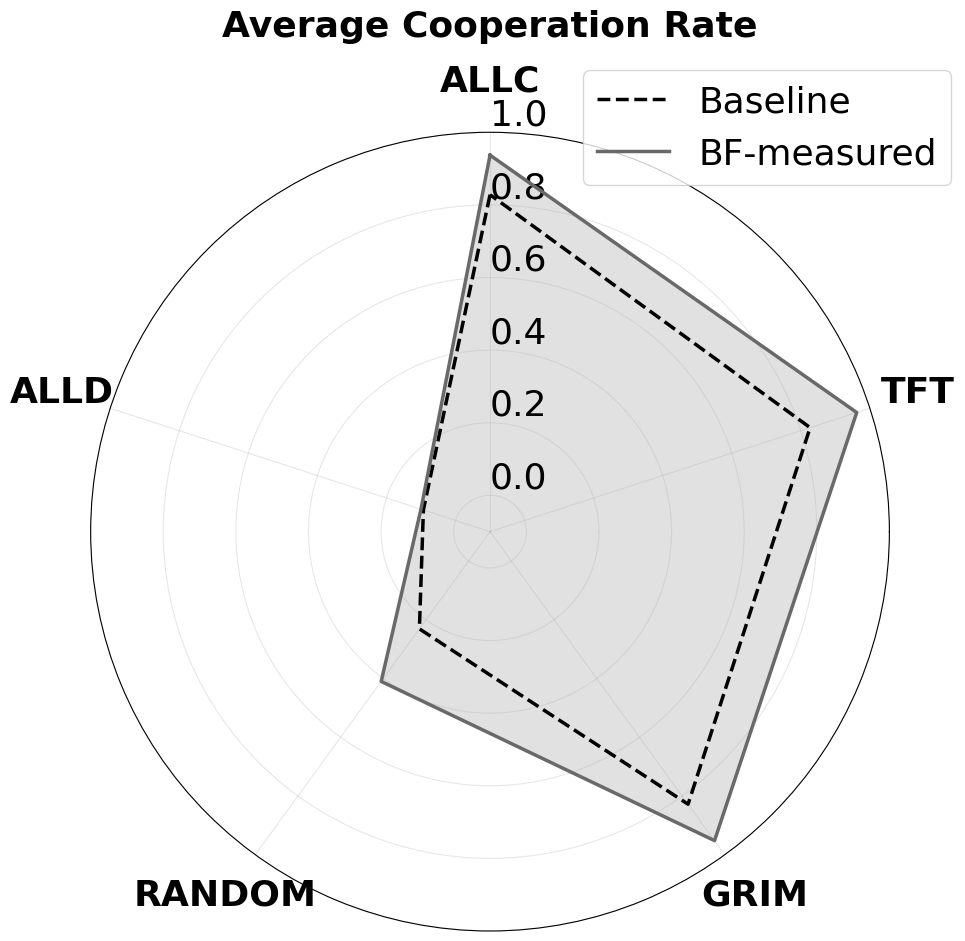

条件別の戦略別協力率レーダーチャートを作成しました


In [27]:
# ===== 可視化: 条件別の戦略別協力率レーダーチャート =====

# 条件別の戦略別平均協力率を計算
condition_strategy_cooperation = df.groupby(['condition', 'strategy'])['cooperation_rate'].mean().reset_index()

# 戦略の順序を設定
strategy_order = ['ALLC', 'ALLD', 'RANDOM', 'GRIM', 'TFT']

# レーダーチャート用の角度を計算（5つの戦略）
# 最初の頂点を真上（π/2）にするために、角度をπ/2だけ回転
angles = np.linspace(0, 2 * np.pi, len(strategy_order), endpoint=False).tolist()
angles = [(angle + np.pi / 2) % (2 * np.pi) for angle in angles]  # π/2だけ回転
angles += angles[:1]  # 閉じるために最初の角度を追加

# 関数: 条件の値を取得
def get_condition_values(condition_strategy_data, condition_name, strategy_order):
    """条件の戦略別値を取得"""
    condition_data = condition_strategy_data[condition_strategy_data['condition'] == condition_name]
    values = []
    for strategy in strategy_order:
        strategy_data = condition_data[condition_data['strategy'] == strategy]
        if not strategy_data.empty:
            values.append(strategy_data['cooperation_rate'].iloc[0])
        else:
            values.append(0)
    values += values[:1]  # 閉じるために最初の値を追加
    return values

# 1. BaselineとMeasuredを重ねて表示
fig1, ax1 = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
ax1.set_position([0.1, 0.1, 0.8, 0.8])  # 中央に寄せる

baseline_values = get_condition_values(condition_strategy_cooperation, 'Baseline', strategy_order)
measured_values = get_condition_values(condition_strategy_cooperation, 'Measured', strategy_order)

ax1.plot(angles, baseline_values, '--', linewidth=2.5, label='Baseline', color='black', markersize=8)
ax1.plot(angles, measured_values, '-', linewidth=2.5, label='BF-measured', color='dimgray', markersize=8)
ax1.fill(angles, measured_values, alpha=0.2, color='dimgray')

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(strategy_order, fontsize=26, fontweight='bold')
ax1.tick_params(axis='x', pad=26)  # ラベルを外側に配置
ax1.set_ylim(-0.1, 1)
ax1.set_title('Average Cooperation Rate', fontsize=26, fontweight='bold', pad=20)
ax1.tick_params(axis='y', labelsize=26) 
ax1.set_rlabel_position(90)
ax1.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1), fontsize=26)
ax1.grid(True)

plt.tight_layout()
plt.savefig('visualizations/gpt5/Average_Cooperation_Rate.svg', dpi=300, bbox_inches='tight')
plt.show()

print("条件別の戦略別協力率レーダーチャートを作成しました")


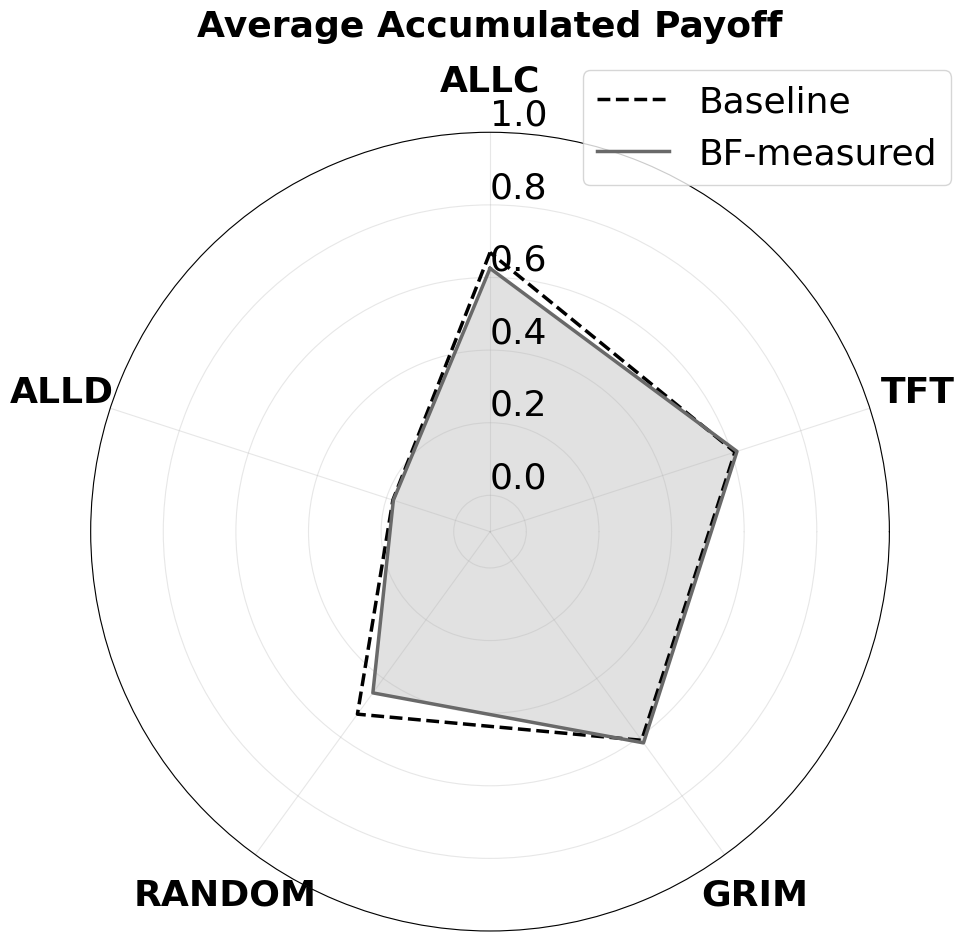

条件別の戦略別ペイオフレーダーチャートを作成しました


In [28]:
# ===== 可視化: 条件別の戦略別ペイオフレーダーチャート =====

# 条件別の戦略別平均ペイオフを計算
condition_strategy_payoff = df.groupby(['condition', 'strategy'])['average_payoff'].mean().reset_index()

# 戦略の順序を設定
strategy_order = ['ALLC', 'ALLD', 'RANDOM', 'GRIM', 'TFT']

# レーダーチャート用の角度を計算（5つの戦略）
# 最初の頂点を真上（π/2）にするために、角度をπ/2だけ回転
angles = np.linspace(0, 2 * np.pi, len(strategy_order), endpoint=False).tolist()
angles = [(angle + np.pi / 2) % (2 * np.pi) for angle in angles]  # π/2だけ回転
angles += angles[:1]  # 閉じるために最初の角度を追加

# 関数: 条件の値を取得（正規化済み：0-1の範囲）
def get_condition_payoff_values(condition_strategy_data, condition_name, strategy_order):
    """条件の戦略別ペイオフ値を取得（50で割って正規化）"""
    condition_data = condition_strategy_data[condition_strategy_data['condition'] == condition_name]
    values = []
    for strategy in strategy_order:
        strategy_data = condition_data[condition_data['strategy'] == strategy]
        if not strategy_data.empty:
            # 利得を50で割って0-1の範囲に正規化
            values.append(strategy_data['average_payoff'].iloc[0] / 50.0)
        else:
            values.append(0)
    values += values[:1]  # 閉じるために最初の値を追加
    return values

# 1. BaselineとMeasuredを重ねて表示
fig1, ax1 = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
ax1.set_position([0.1, 0.1, 0.8, 0.8])  # 中央に寄せる

baseline_values = get_condition_payoff_values(condition_strategy_payoff, 'Baseline', strategy_order)
measured_values = get_condition_payoff_values(condition_strategy_payoff, 'Measured', strategy_order)

ax1.plot(angles, baseline_values, '--', linewidth=2.5, label='Baseline', color='black', markersize=8)
ax1.plot(angles, measured_values, '-', linewidth=2.5, label='BF-measured', color='dimgray', markersize=8)
ax1.fill(angles, measured_values, alpha=0.2, color='dimgray')

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(strategy_order, fontsize=26, fontweight='bold')
ax1.tick_params(axis='x', pad=26)  # ラベルを外側に配置
ax1.set_ylim(-0.1, 1)  # 正規化済みなので0-1の範囲
ax1.set_title('Average Accumulated Payoff', fontsize=26, fontweight='bold', pad=20)
ax1.tick_params(axis='y', labelsize=26) 
ax1.set_rlabel_position(90)
ax1.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1), fontsize=26)
ax1.grid(True)

plt.tight_layout()
plt.savefig('visualizations/gpt5/Average_Accumulated_Payoff.svg', dpi=300, bbox_inches='tight')
plt.show()


print("条件別の戦略別ペイオフレーダーチャートを作成しました")


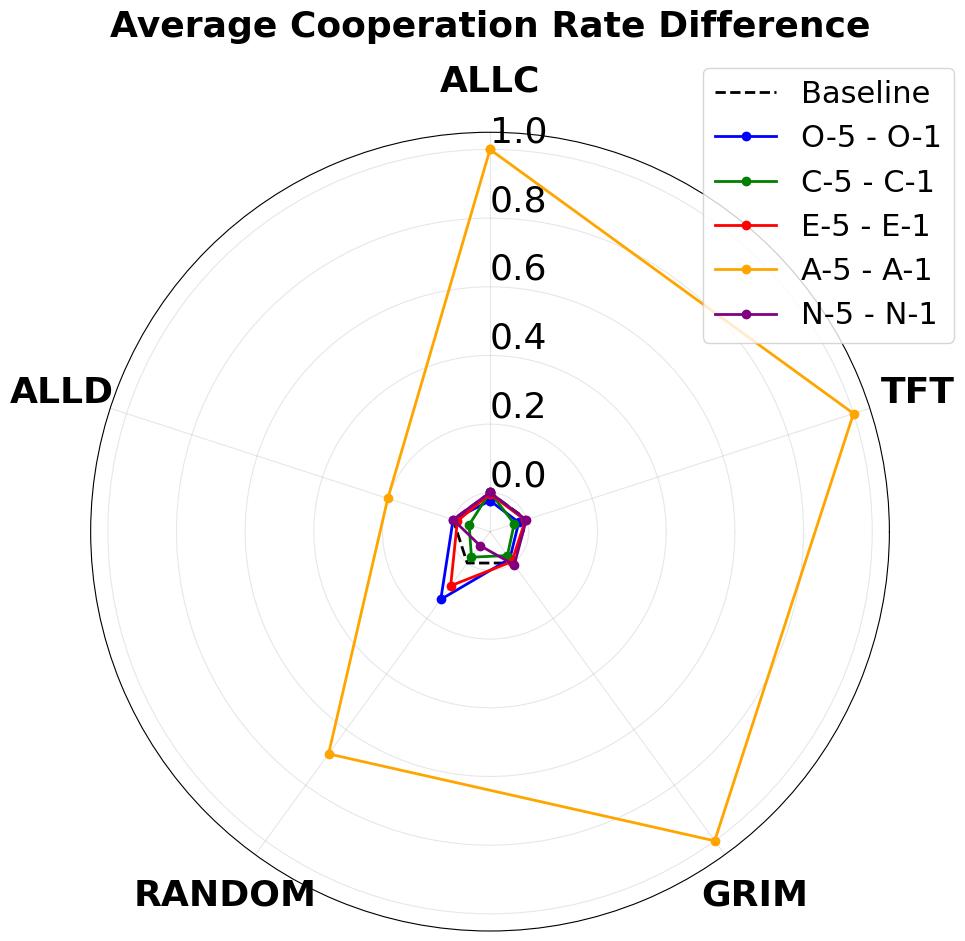

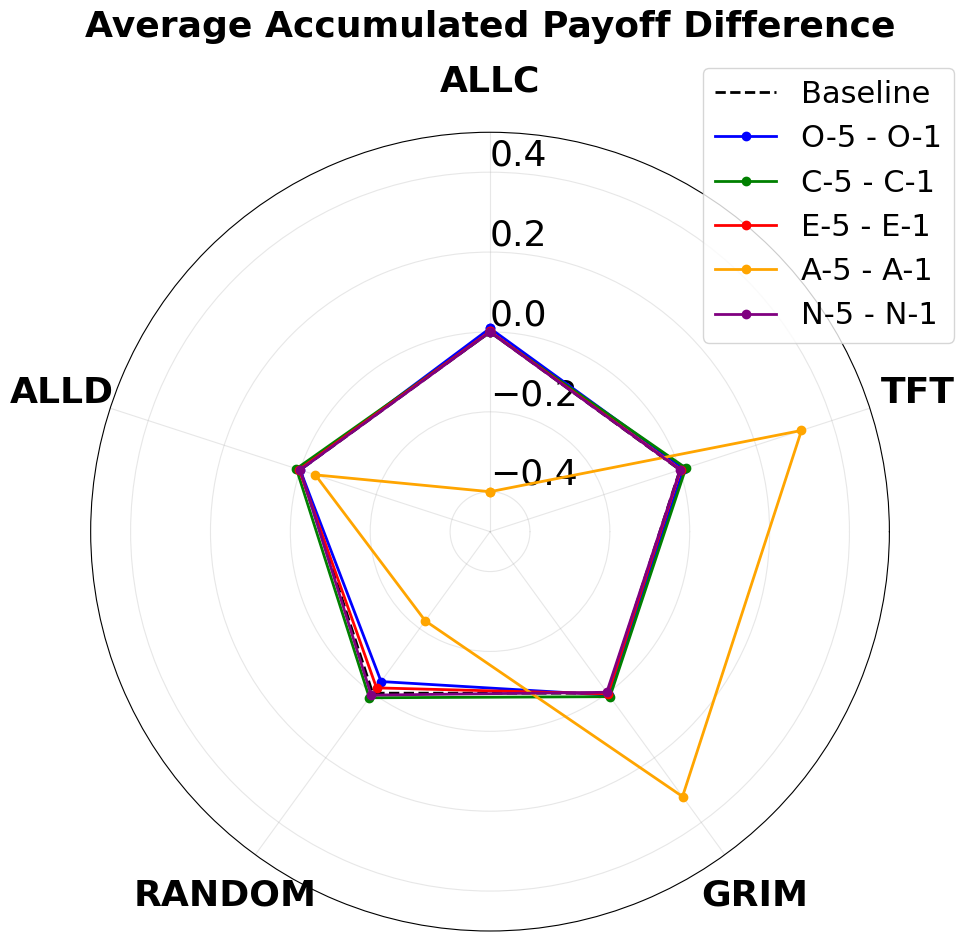

スコア1とスコア5の差分レーダーチャートを作成しました

=== スコア5 - スコア1の差分統計 ===

協力率の差分:
Openness (O): 平均差分 = 0.0136
Conscientiousness (C): 平均差分 = -0.0268
Extraversion (E): 平均差分 = 0.0112
Agreeableness (A): 平均差分 = 0.7774
Neuroticism (N): 平均差分 = -0.0114

ペイオフの差分:
Openness (O): 平均差分 = -0.00
Conscientiousness (C): 平均差分 = 0.01
Extraversion (E): 平均差分 = -0.00
Agreeableness (A): 平均差分 = -0.00
Neuroticism (N): 平均差分 = 0.00


In [29]:
# ===== 可視化: スコア1とスコア5の差分レーダーチャート =====

# 条件別の戦略別平均協力率を計算
condition_strategy_cooperation = df.groupby(['condition', 'strategy'])['cooperation_rate'].mean().reset_index()

# 条件別の戦略別平均ペイオフを計算
condition_strategy_payoff = df.groupby(['condition', 'strategy'])['average_payoff'].mean().reset_index()

# 戦略の順序を設定
strategy_order = ['ALLC', 'ALLD', 'RANDOM', 'GRIM', 'TFT']

# レーダーチャート用の角度を計算（5つの戦略）
angles = np.linspace(0, 2 * np.pi, len(strategy_order), endpoint=False).tolist()
angles = [(angle + np.pi / 2) % (2 * np.pi) for angle in angles]  # π/2だけ回転
angles += angles[:1]  # 閉じるために最初の角度を追加

# 関数: 条件の協力率値を取得
def get_condition_cooperation_values(condition_strategy_data, condition_name, strategy_order):
    """条件の戦略別協力率値を取得"""
    condition_data = condition_strategy_data[condition_strategy_data['condition'] == condition_name]
    values = []
    for strategy in strategy_order:
        strategy_data = condition_data[condition_data['strategy'] == strategy]
        if not strategy_data.empty:
            values.append(strategy_data['cooperation_rate'].iloc[0])
        else:
            values.append(0)
    values += values[:1]  # 閉じるために最初の値を追加
    return values

# 関数: 条件のペイオフ値を取得（正規化済み：0-1の範囲）
def get_condition_payoff_values(condition_strategy_data, condition_name, strategy_order):
    """条件の戦略別ペイオフ値を取得（50で割って正規化）"""
    condition_data = condition_strategy_data[condition_strategy_data['condition'] == condition_name]
    values = []
    for strategy in strategy_order:
        strategy_data = condition_data[condition_data['strategy'] == strategy]
        if not strategy_data.empty:
            # 利得を50で割って0-1の範囲に正規化
            values.append(strategy_data['average_payoff'].iloc[0] / 50.0)
        else:
            values.append(0)
    values += values[:1]  # 閉じるために最初の値を追加
    return values

# 性格特性のリスト
personality_traits = ['O', 'C', 'E', 'A', 'N']
trait_names = ['Openness', 'Conscientiousness', 'Extraversion', 'Agreeableness', 'Neuroticism']
# 色の統一: 開放性=青、誠実性=緑、外向性=赤、協調性=オレンジ、神経症傾向=紫
trait_colors = ['blue', 'green', 'red', 'orange', 'purple']

# ===== 1. 協力率の差分レーダーチャート =====
fig1, ax1 = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
ax1.set_position([0.1, 0.1, 0.8, 0.8])  # 中央に寄せる

# ゼロライン（差分なので0が基準）
zero_line = [0] * len(angles)
ax1.plot(angles, zero_line, '--', linewidth=2, label='Baseline', color='black')

# 各性格特性について、スコア5とスコア1の差分を計算
all_diff_values_cooperation = []
for i, trait in enumerate(personality_traits):
    score_1_condition = f'{trait}-1'
    score_5_condition = f'{trait}-5'
    
    score_1_values = get_condition_cooperation_values(condition_strategy_cooperation, score_1_condition, strategy_order)
    score_5_values = get_condition_cooperation_values(condition_strategy_cooperation, score_5_condition, strategy_order)
    
    # スコア5 - スコア1の差分を計算
    diff_values = [v5 - v1 for v5, v1 in zip(score_5_values, score_1_values)]
    all_diff_values_cooperation.extend(diff_values)
    
    ax1.plot(angles, diff_values, 'o-', linewidth=2, label=f'{trait}-5 - {trait}-1', 
             color=trait_colors[i], markersize=6)

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(strategy_order, fontsize=26, fontweight='bold')
ax1.tick_params(axis='x', pad=26)  # ラベルを外側に配置

# 差分の範囲に合わせてy軸の範囲を調整
if all_diff_values_cooperation:
    y_min = min(all_diff_values_cooperation) - 0.05
    y_max = max(all_diff_values_cooperation) + 0.05
    ax1.set_ylim(y_min, y_max)

ax1.set_title('Average Cooperation Rate Difference', fontsize=26, fontweight='bold', pad=20)
ax1.tick_params(axis='y', labelsize=26)
ax1.set_rlabel_position(90)
ax1.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1), fontsize=22)
ax1.grid(True)

plt.tight_layout()
plt.savefig('visualizations/gpt5/Average_Cooperation_Rate_Difference.svg', dpi=300, bbox_inches='tight')
plt.show()

# ===== 2. ペイオフの差分レーダーチャート =====
fig2, ax2 = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
ax2.set_position([0.1, 0.1, 0.8, 0.8])  # 中央に寄せる

# ゼロライン（差分なので0が基準）
zero_line = [0] * len(angles)
ax2.plot(angles, zero_line, '--', linewidth=2, label='Baseline', color='black')

# 各性格特性について、スコア5とスコア1の差分を計算
all_diff_values_payoff = []
for i, trait in enumerate(personality_traits):
    score_1_condition = f'{trait}-1'
    score_5_condition = f'{trait}-5'
    
    score_1_values = get_condition_payoff_values(condition_strategy_payoff, score_1_condition, strategy_order)
    score_5_values = get_condition_payoff_values(condition_strategy_payoff, score_5_condition, strategy_order)
    
    # スコア5 - スコア1の差分を計算
    diff_values = [v5 - v1 for v5, v1 in zip(score_5_values, score_1_values)]
    all_diff_values_payoff.extend(diff_values)
    
    ax2.plot(angles, diff_values, 'o-', linewidth=2, label=f'{trait}-5 - {trait}-1', 
             color=trait_colors[i], markersize=6)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(strategy_order, fontsize=26, fontweight='bold')
ax2.tick_params(axis='x', pad=26)  # ラベルを外側に配置

# 差分の範囲に合わせてy軸の範囲を調整（正規化済みの値の差分）
if all_diff_values_payoff:
    # 正規化済みの差分なので、適切なマージンを設定
    y_min = min(all_diff_values_payoff)
    y_max = max(all_diff_values_payoff)
    # 対称的な範囲にするため、絶対値の大きい方を使用
    max_abs = max(abs(y_min), abs(y_max))
    y_min = -max_abs - 0.1
    y_max = max_abs + 0.1
    ax2.set_ylim(y_min, y_max)

ax2.set_title('Average Accumulated Payoff Difference', fontsize=26, fontweight='bold', pad=20)
ax2.tick_params(axis='y', labelsize=26)
ax2.set_rlabel_position(90)
ax2.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1), fontsize=22)
ax2.grid(True)

plt.tight_layout()
plt.savefig('visualizations/gpt5/Average_Accumulated_Payoff_Difference.svg', dpi=300, bbox_inches='tight')
plt.show()

print("スコア1とスコア5の差分レーダーチャートを作成しました")

# 統計情報を表示
print("\n=== スコア5 - スコア1の差分統計 ===")
print("\n協力率の差分:")
for i, trait in enumerate(personality_traits):
    score_1_condition = f'{trait}-1'
    score_5_condition = f'{trait}-5'
    
    score_1_values = get_condition_cooperation_values(condition_strategy_cooperation, score_1_condition, strategy_order)
    score_5_values = get_condition_cooperation_values(condition_strategy_cooperation, score_5_condition, strategy_order)
    
    # スコア5 - スコア1の差分を計算（最後の要素は重複なので除外）
    diff_values = [v5 - v1 for v5, v1 in zip(score_5_values[:-1], score_1_values[:-1])]
    avg_diff = np.mean(diff_values)
    print(f"{trait_names[i]} ({trait}): 平均差分 = {avg_diff:.4f}")

print("\nペイオフの差分:")
for i, trait in enumerate(personality_traits):
    score_1_condition = f'{trait}-1'
    score_5_condition = f'{trait}-5'
    
    score_1_values = get_condition_payoff_values(condition_strategy_payoff, score_1_condition, strategy_order)
    score_5_values = get_condition_payoff_values(condition_strategy_payoff, score_5_condition, strategy_order)
    
    # スコア5 - スコア1の差分を計算（最後の要素は重複なので除外）
    diff_values = [v5 - v1 for v5, v1 in zip(score_5_values[:-1], score_1_values[:-1])]
    avg_diff = np.mean(diff_values)
    print(f"{trait_names[i]} ({trait}): 平均差分 = {avg_diff:.2f}")


=== 協力率のスコア1のレーダーチャートを作成中 ===


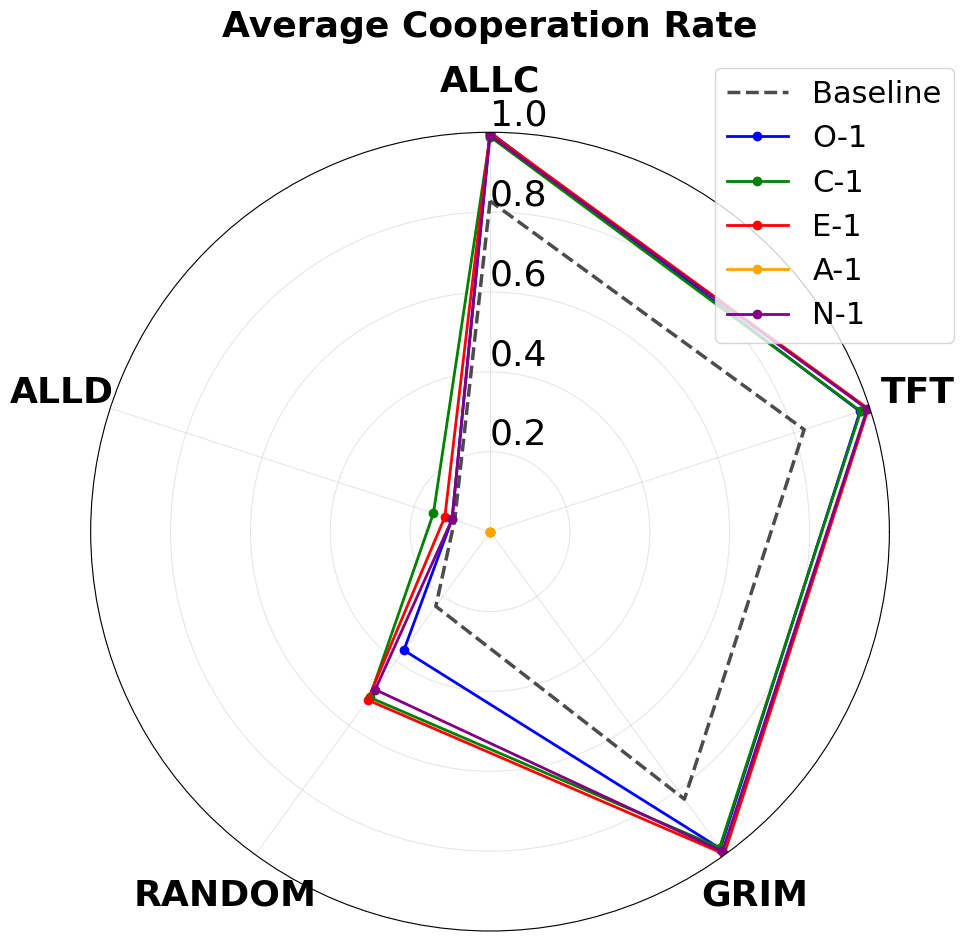

=== 協力率のスコア5のレーダーチャートを作成中 ===


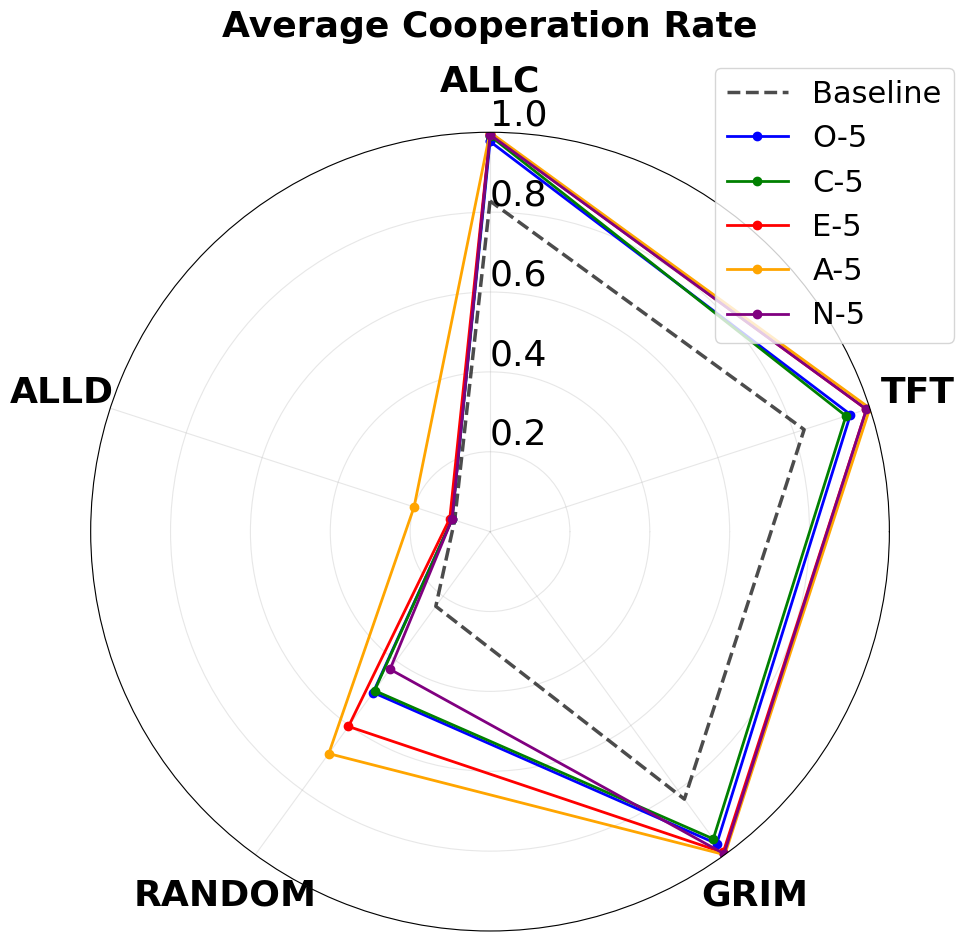

協力率の性格特性ごとのレーダーチャートを作成しました

=== ペイオフのスコア1のレーダーチャートを作成中 ===


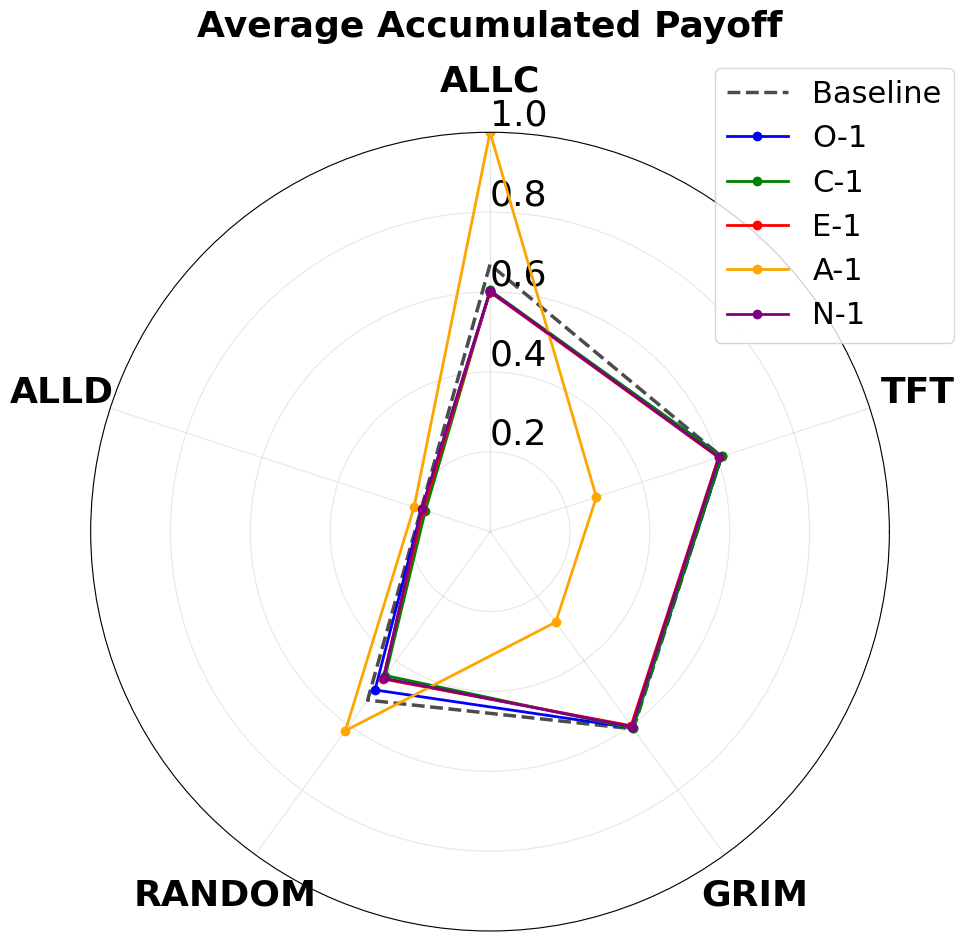

=== ペイオフのスコア5のレーダーチャートを作成中 ===


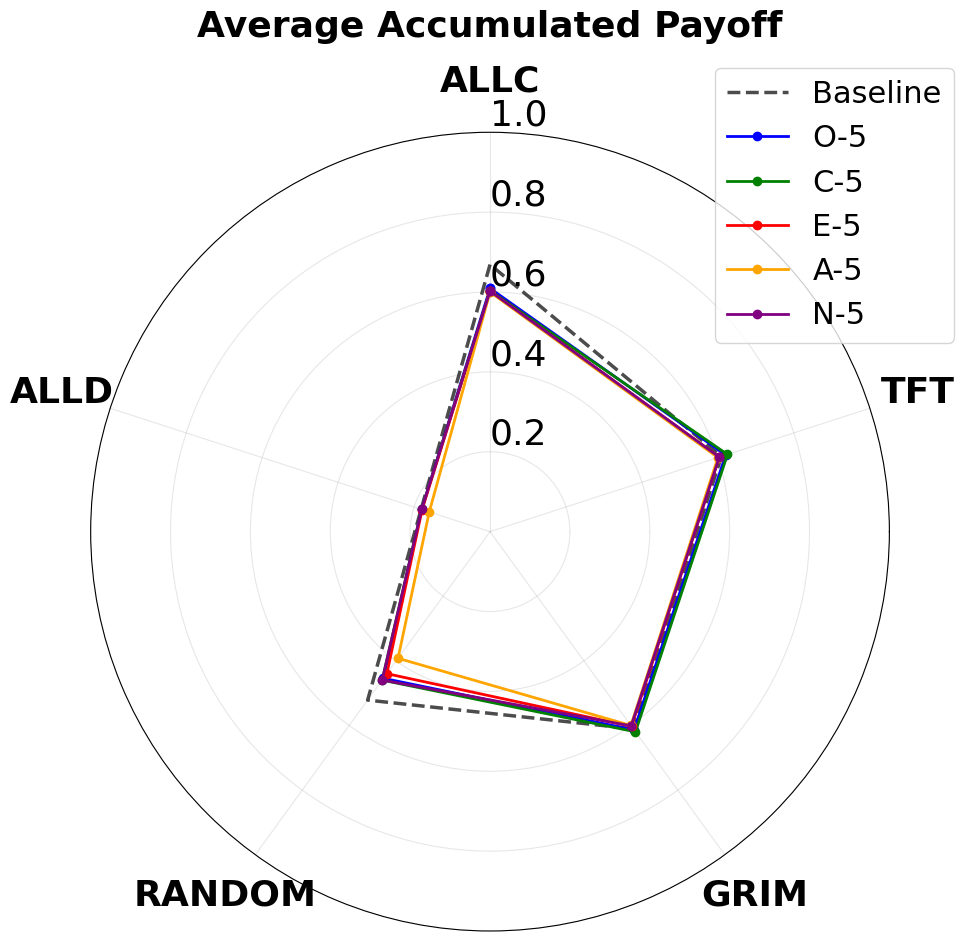

ペイオフの性格特性ごとのレーダーチャートを作成しました


In [30]:
# ===== 可視化: BaselineとMeasuredの実際の形状を基準とした性格特性ごとのレーダーチャート =====

# 条件別の戦略別平均協力率を計算
condition_strategy_cooperation = df.groupby(['condition', 'strategy'])['cooperation_rate'].mean().reset_index()

# 条件別の戦略別平均ペイオフを計算
condition_strategy_payoff = df.groupby(['condition', 'strategy'])['average_payoff'].mean().reset_index()

# 戦略の順序を設定
strategy_order = ['ALLC', 'ALLD', 'RANDOM', 'GRIM', 'TFT']

# レーダーチャート用の角度を計算（5つの戦略）
angles = np.linspace(0, 2 * np.pi, len(strategy_order), endpoint=False).tolist()
angles = [(angle + np.pi / 2) % (2 * np.pi) for angle in angles]  # π/2だけ回転
angles += angles[:1]  # 閉じるために最初の角度を追加

# 関数: 条件の協力率値を取得
def get_condition_cooperation_values(condition_strategy_data, condition_name, strategy_order):
    """条件の戦略別協力率値を取得"""
    condition_data = condition_strategy_data[condition_strategy_data['condition'] == condition_name]
    values = []
    for strategy in strategy_order:
        strategy_data = condition_data[condition_data['strategy'] == strategy]
        if not strategy_data.empty:
            values.append(strategy_data['cooperation_rate'].iloc[0])
        else:
            values.append(0)
    values += values[:1]  # 閉じるために最初の値を追加
    return values

# 関数: 条件のペイオフ値を取得（正規化済み：0-1の範囲）
def get_condition_payoff_values(condition_strategy_data, condition_name, strategy_order):
    """条件の戦略別ペイオフ値を取得（50で割って正規化）"""
    condition_data = condition_strategy_data[condition_strategy_data['condition'] == condition_name]
    values = []
    for strategy in strategy_order:
        strategy_data = condition_data[condition_data['strategy'] == strategy]
        if not strategy_data.empty:
            # 利得を50で割って0-1の範囲に正規化
            values.append(strategy_data['average_payoff'].iloc[0] / 50.0)
        else:
            values.append(0)
    values += values[:1]  # 閉じるために最初の値を追加
    return values

# Baselineの値を取得
baseline_cooperation = get_condition_cooperation_values(condition_strategy_cooperation, 'Baseline', strategy_order)
baseline_payoff = get_condition_payoff_values(condition_strategy_payoff, 'Baseline', strategy_order)

# 性格特性のリスト
personality_traits = ['O', 'C', 'E', 'A', 'N']
trait_names = ['Openness', 'Conscientiousness', 'Extraversion', 'Agreeableness', 'Neuroticism']
# 色の統一: 開放性=青、誠実性=緑、外向性=赤、協調性=オレンジ、神経症傾向=紫
trait_colors = ['blue', 'green', 'red', 'orange', 'purple']

# ===== 1. 協力率のスコア1をまとめて表示（Baselineの基準線付き） =====
print("=== 協力率のスコア1のレーダーチャートを作成中 ===")

fig1, ax1 = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
ax1.set_position([0.1, 0.1, 0.8, 0.8])  # 中央に寄せる

score_1_conditions = ['O-1', 'C-1', 'E-1', 'A-1', 'N-1']

# Baselineの実際の形状を基準として表示
ax1.plot(angles, baseline_cooperation, '--', linewidth=2.5, label='Baseline', color='black', alpha=0.7)

# 各性格特性のスコア1の実際の値を表示
for i, condition in enumerate(score_1_conditions):
    values = get_condition_cooperation_values(condition_strategy_cooperation, condition, strategy_order)
    ax1.plot(angles, values, 'o-', linewidth=2, label=condition, color=trait_colors[i], markersize=6)

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(strategy_order, fontsize=26, fontweight='bold')
ax1.tick_params(axis='x', pad=26)  # ラベルを外側に配置
ax1.set_ylim(0, 1)
ax1.set_title('Average Cooperation Rate', fontsize=26, fontweight='bold', pad=20)
ax1.tick_params(axis='y', labelsize=26)
ax1.set_rlabel_position(90)
ax1.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1), fontsize=22)
ax1.grid(True)

plt.tight_layout()
plt.savefig('visualizations/gpt5/Average_Cooperation_Rate_1.svg', 
            dpi=300, bbox_inches='tight')
plt.show()

# ===== 2. 協力率のスコア5をまとめて表示（Baselineの基準線付き） =====
print("=== 協力率のスコア5のレーダーチャートを作成中 ===")

fig2, ax2 = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
ax2.set_position([0.1, 0.1, 0.8, 0.8])  # 中央に寄せる

score_5_conditions = ['O-5', 'C-5', 'E-5', 'A-5', 'N-5']

# Baselineの実際の形状を基準として表示
ax2.plot(angles, baseline_cooperation, '--', linewidth=2.5, label='Baseline', color='black', alpha=0.7)

# 各性格特性のスコア5の実際の値を表示
for i, condition in enumerate(score_5_conditions):
    values = get_condition_cooperation_values(condition_strategy_cooperation, condition, strategy_order)
    ax2.plot(angles, values, 'o-', linewidth=2, label=condition, color=trait_colors[i], markersize=6)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(strategy_order, fontsize=26, fontweight='bold')
ax2.tick_params(axis='x', pad=26)  # ラベルを外側に配置
ax2.set_ylim(0, 1)
ax2.set_title('Average Cooperation Rate', fontsize=26, fontweight='bold', pad=20)
ax2.tick_params(axis='y', labelsize=26)
ax2.set_rlabel_position(90)
ax2.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1), fontsize=22)
ax2.grid(True)

plt.tight_layout()
plt.savefig('visualizations/gpt5/Average_Cooperation_Rate_5.svg', 
            dpi=300, bbox_inches='tight')
plt.show()

print("協力率の性格特性ごとのレーダーチャートを作成しました")

# ===== 3. ペイオフのスコア1をまとめて表示（Baselineの基準線付き） =====
print("\n=== ペイオフのスコア1のレーダーチャートを作成中 ===")

fig3, ax3 = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
ax3.set_position([0.1, 0.1, 0.8, 0.8])  # 中央に寄せる

score_1_conditions = ['O-1', 'C-1', 'E-1', 'A-1', 'N-1']

# Baselineの実際の形状を基準として表示
ax3.plot(angles, baseline_payoff, '--', linewidth=2.5, label='Baseline', color='black', alpha=0.7)

# 各性格特性のスコア1の実際の値を表示
for i, condition in enumerate(score_1_conditions):
    values = get_condition_payoff_values(condition_strategy_payoff, condition, strategy_order)
    ax3.plot(angles, values, 'o-', linewidth=2, label=condition, color=trait_colors[i], markersize=6)

ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(strategy_order, fontsize=26, fontweight='bold')
ax3.tick_params(axis='x', pad=26)  # ラベルを外側に配置
ax3.set_ylim(0, 1)  # 正規化済みなので0-1の範囲
ax3.set_title('Average Accumulated Payoff', fontsize=26, fontweight='bold', pad=20)
ax3.tick_params(axis='y', labelsize=26)
ax3.set_rlabel_position(90)
ax3.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1), fontsize=22)
ax3.grid(True)

plt.tight_layout()
plt.savefig('visualizations/gpt5/Average_Accumulated_Payoff_1.svg', 
            dpi=300, bbox_inches='tight')
plt.show()

# ===== 4. ペイオフのスコア5をまとめて表示（Baselineの基準線付き） =====
print("=== ペイオフのスコア5のレーダーチャートを作成中 ===")

fig4, ax4 = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
ax4.set_position([0.1, 0.1, 0.8, 0.8])  # 中央に寄せる

score_5_conditions = ['O-5', 'C-5', 'E-5', 'A-5', 'N-5']

# Baselineの実際の形状を基準として表示
ax4.plot(angles, baseline_payoff, '--', linewidth=2.5, label='Baseline', color='black', alpha=0.7)

# 各性格特性のスコア5の実際の値を表示
for i, condition in enumerate(score_5_conditions):
    values = get_condition_payoff_values(condition_strategy_payoff, condition, strategy_order)
    ax4.plot(angles, values, 'o-', linewidth=2, label=condition, color=trait_colors[i], markersize=6)

ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(strategy_order, fontsize=26, fontweight='bold')
ax4.tick_params(axis='x', pad=26)  # ラベルを外側に配置
ax4.set_ylim(0, 1)  # 正規化済みなので0-1の範囲
ax4.set_title('Average Accumulated Payoff', fontsize=26, fontweight='bold', pad=20)
ax4.tick_params(axis='y', labelsize=26)
ax4.set_rlabel_position(90)
ax4.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1), fontsize=22)
ax4.grid(True)

plt.tight_layout()
plt.savefig('visualizations/gpt5/Average_Accumulated_Payoff_5.svg', 
            dpi=300, bbox_inches='tight')
plt.show()

print("ペイオフの性格特性ごとのレーダーチャートを作成しました")
